# Prefilter Model — Inference Report

Evaluate the trained prefilter (DA) model on:
1. **MC test set** — parts not used in training (complement of `prefilter_h5_parts.json`)
2. **Experimental data** — `exp.h5` (raw hits only)
3. **Experimental reco data** — `exp_reco.h5` (raw hits + reconstruction features)

In [1]:
import datetime
import sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import list_h5_parts, load_model, load_mc_test_parts, \
    load_exp_parts, predict_scores, plot_event_3d

%load_ext autoreload
%autoreload 2

## Configuration

TODO: check if hard labeled model does better with Reco sample

In [2]:
# ── Paths ──

#MODEL_NAME = "da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss" #da_prefilter_numu_260401_0735_hardlabels_lambda0.3_zflipBothMCExp
MODEL_NAME = "da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss"
#CHECKPOINT_PATH = "experiments/numu/da_prefilter_numu_260327_0127/best_da_model.pth"
#CHECKPOINT_PATH = "experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth"
CHECKPOINT_PATH = f"experiments/numu/{MODEL_NAME}/best_da_model.pth"
TRAIN_PARTS_JSON = "/home/albert/Baikal2025/data_manager/datasets/baikal_mc2020_prefilter/prefilter_h5_parts.json"
MC_H5_PATH = "/home/albert/Baikal2025/data_manager/data/h5datasets/baikal_mc_merged.h5"
EXP_H5_PATH = "data_manager/data/h5datasets/exp.h5"
EXP_RECO_H5_PATH = "data_manager/data/h5datasets/exp_reco.h5"

# ── Figures output directory ──
TIMESTAMP_STR = datetime.datetime.now().strftime("%y%m%d_%H%M%S")
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/figures_{TIMESTAMP_STR}"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=150, bbox_inches="tight")
    print(f"Saved: {fig_path}")

# ── MC test parts to load (from complement of training parts) ──
N_PARTS_PER_PARTICLE = {
    "muatm": 16,
    "nue2": 8,
    "nuatm": 8,
}

reco_parts = list_h5_parts(str(PROJECT_ROOT / EXP_RECO_H5_PATH), 'exp_reco')
BAD_RECO_PARTS = [
    p for p in reco_parts if 'c01' in p
]

# ── Inference settings ──
DEVICE = "cuda:2"
BATCH_SIZE = 1024
MAX_HITS = 500
SEED = 42

# Recomended cuts:
# thetaRec      < 80
# nHits         >= 8
# nStrings      >= 2
# covMatrixStatus == 3
# scfMaxTheta   < 1.7
# log10(pHit)   > -9  # Questionable mapping with the slides
# evCenterZ     < 220
# zDist         > 70
# pathLength    > 50
# log10(funcValue / (nHits - 5)) < 1.1  # Questionable mapping with the slides
# nTriplets / nHits > 0.1
# thetaErr      < 2.5
# nCalls        < 350

def get_mask(df, theta_cuts=(0, 30)):
    mask = np.ones(len(df), dtype=bool)
    mask = mask & (df['thetaRec'] > theta_cuts[0]) & (df['thetaRec'] <= theta_cuts[1])
    mask = mask & (df['nHits'] >= 8)
    mask = mask & (df['nStrings'] >= 2)
    mask = mask & (df['covMatrixStatus'] == 3)
    mask = mask & (df['scfMaxTheta'] < 1.7)
    mask = mask & (np.log10(df['pHit']) > -9.)
    mask = mask & (df['evCenterZ'] < 220)
    mask = mask & (df['zDist'] > 70)
    mask = mask & (df['pathLength'] > 50)
    mask = mask & (np.log10(df['funcValue'] / (df['nHits'] - 5)) < 2.)
    mask = mask & (df['nTriplets'] / df['nHits'] > 0.1)
    mask = mask & (df['thetaErr'] < 2.5)
    mask = mask & (df['nCalls'] < 350)
    return mask

## 1. Load model

In [3]:
model, norm_config, train_config = load_model(
    str(PROJECT_ROOT / CHECKPOINT_PATH), device=DEVICE
)
print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")
print(f"Model amp_clip: {model.amp_clip:.4f} (normalized) "
      f"= Q≈{model.amp_clip * norm_config['stds'][0] + norm_config['means'][0]:.1f} PE")


2026-05-01 19:30:57,473 INFO Created AttentionFeatureExtractor: 5→128, 4 layers, 4 heads, pooling=cls
2026-05-01 19:30:57,474 INFO Created BinaryClassifier: 128→[32, 16]→1, dropout=0.0, batch_norm=False
2026-05-01 19:30:57,475 INFO Created StandardNeutrinoModel with 404161 parameters
2026-05-01 19:30:57,479 INFO amp_clip: Q=100 PE → normalized=1.6333 (mean=2.0, std=60.0)
2026-05-01 19:30:57,482 INFO Loaded model from epoch 46 (best_metric=0.9926)


Normalization: means=[2.0, 0.0, 0.0, 0.0, 0.0], stds=[60.0, 1370.0, 40.0, 40.0, 150.0]
Model amp_clip: 1.6333 (normalized) = Q≈100.0 PE


## 2. Load data

In [4]:
# MC test set (complement of training parts)
df_mc = load_mc_test_parts(
    h5_path=MC_H5_PATH,
    train_parts_json=TRAIN_PARTS_JSON,
    n_parts_per_particle=N_PARTS_PER_PARTICLE,
    seed=SEED,
)
print(f"MC test: {len(df_mc):,} events")
print(df_mc["particle_type"].value_counts())

2026-05-01 19:31:24,278 INFO Loading 16 test parts for muatm_2020 (complement of 432 training parts)


MC muatm:   0%|          | 0/16 [00:00<?, ?part/s]

2026-05-01 19:31:33,272 INFO Loading 8 test parts for nue2_2020 (complement of 333 training parts)


MC nue2:   0%|          | 0/8 [00:00<?, ?part/s]

2026-05-01 19:31:38,711 INFO Loading 8 test parts for nuatm_2020 (complement of 187 training parts)


MC nuatm:   0%|          | 0/8 [00:00<?, ?part/s]

2026-05-01 19:31:45,718 INFO MC test set: 899,305 events loaded


MC test: 899,305 events
particle_type
muatm_2020    467494
nuatm_2020    281598
nue2_2020     150213
Name: count, dtype: int64


In [5]:
# Experimental data (raw)
df_exp = load_exp_parts(
    h5_path=str(PROJECT_ROOT / EXP_H5_PATH),
    group_name="exp",
    max_events=1_000_000
)
print(f"Exp: {len(df_exp):,} events")


Exp exp:   0%|          | 0/26 [00:00<?, ?part/s]

2026-05-01 19:31:58,051 INFO Loaded 649,976 events from /home/albert/Baikal2025/data_manager/data/h5datasets/exp.h5 (exp)


Exp: 649,976 events


In [6]:
# Filter out exp parts, that were used in train
with open(PROJECT_ROOT / Path(CHECKPOINT_PATH).parent / "used_target_event_ids.txt") as f:
    used_ids = [('_'.join(l.strip().split('_')[:-1]).replace("exp", "part"), l.strip().split('_')[-1]) for l in f.readlines()]
used_ids = pd.DataFrame(used_ids, columns=['h5_part_str', 'local_id'])

used_ids['local_id'] = used_ids['local_id'].astype(df_exp['local_id'].dtype)
used_idx = pd.MultiIndex.from_frame(used_ids[['h5_part_str', 'local_id']])
df_exp_idx = pd.MultiIndex.from_arrays([df_exp['h5_part_str'], df_exp['local_id']])
df_exp = df_exp[~df_exp_idx.isin(used_idx)]

In [7]:
# Experimental reco data (raw + reco_prty)
df_exp_reco = load_exp_parts(
    h5_path=str(PROJECT_ROOT / EXP_RECO_H5_PATH),
    group_name="exp_reco",
    load_reco=True,
    parts_to_load=[p for p in reco_parts if p not in BAD_RECO_PARTS][0:10]
)

df_exp_reco = df_exp_reco[(~df_exp_reco['h5_part_str'].isin(BAD_RECO_PARTS))]

print(f"Exp reco: {len(df_exp_reco):,} events")
from inference.prefilter_model.utils import EXP_RECO_COL_NAMES
reco_cols = [c for c in df_exp_reco.columns if c in EXP_RECO_COL_NAMES]
print(f"Reco columns ({len(reco_cols)}): {reco_cols}")

Exp exp_reco:   0%|          | 0/10 [00:00<?, ?part/s]

2026-05-01 19:32:06,437 INFO Loaded 325,522 events from /home/albert/Baikal2025/data_manager/data/h5datasets/exp_reco.h5 (exp_reco)


Exp reco: 325,522 events
Reco columns (25): ['thetaRec', 'phiRec', 'thetaErr', 'phiErr', 'funcValue', 'timeChi2', 'chargeTerm', 'LLFit', 'nHits', 'nStrings', 'nOMs', 'pathLength', 'timeXYZRec', 'covMatrixStatus', 'scfMaxTheta', 'scfMinTheta', 'scfTheta', 'scfPhi', 'pHit', 'evCenterZ', 'zDist', 'nTriplets', 'nCalls', 'classBDT', 'classBDTLowE']


In [8]:
## Filter events having max Q >1e4 ev
maxq = np.array([x[:, 0].max() for x in df_exp_reco['features']])
df_exp_reco = df_exp_reco[maxq <= 1e4].reset_index(drop=True)

In [9]:
get_mask(df_exp_reco).sum()

np.int64(12)

In [10]:
print("Creating reco sample with fix number of events, but including ALL the 'upgoing' events")
df_upgoing = df_exp_reco[get_mask(df_exp_reco)]
df_exp_reco_sample = df_exp_reco.sample(n=min(500_000, len(df_exp_reco)))
df_exp_reco_sample =  pd.concat([df_exp_reco_sample, df_upgoing])
df_exp_reco_sample = df_exp_reco_sample[~df_exp_reco_sample.index.duplicated(keep='first')]

Creating reco sample with fix number of events, but including ALL the 'upgoing' events


## 3. Predict scores

In [11]:
df_mc["score"] = predict_scores(
    model, df_mc["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"MC scores: mean={df_mc['score'].mean():.4f}, median={df_mc['score'].median():.4f}")

Predicting:   0%|          | 0/879 [00:00<?, ?batch/s]

/home/albert/miniconda3/envs/baikal25/lib/python3.10/site-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


MC scores: mean=0.4998, median=0.3825


In [12]:
df_exp["score"] = predict_scores(
    model, df_exp["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"Exp scores: mean={df_exp['score'].mean():.4f}, median={df_exp['score'].median():.4f}")

Predicting:   0%|          | 0/245 [00:00<?, ?batch/s]

Exp scores: mean=0.3460, median=0.3592


In [13]:
print("Prediction...")
df_exp_reco.loc[df_exp_reco_sample.index, "score"] = predict_scores(
    model, df_exp_reco_sample["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"Exp reco scores: mean={df_exp_reco['score'].mean():.4f}, median={df_exp_reco['score'].median():.4f}")

Prediction...


Predicting:   0%|          | 0/318 [00:00<?, ?batch/s]

Exp reco scores: mean=0.0214, median=0.0025


## 4. Score distributions (MC by particle type)

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_per_particle.png


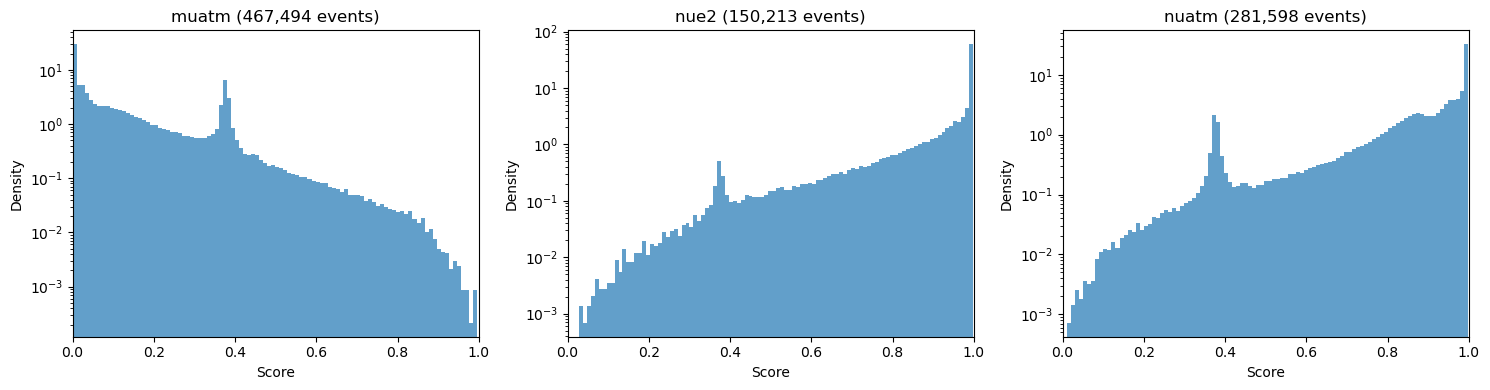

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_exp.png


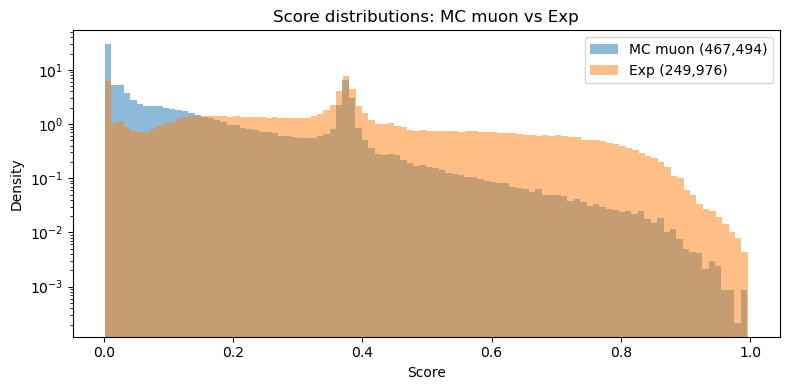

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta10.png


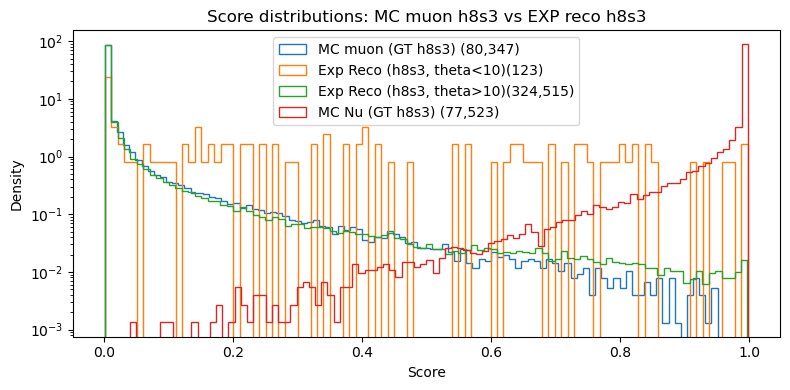

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta20.png


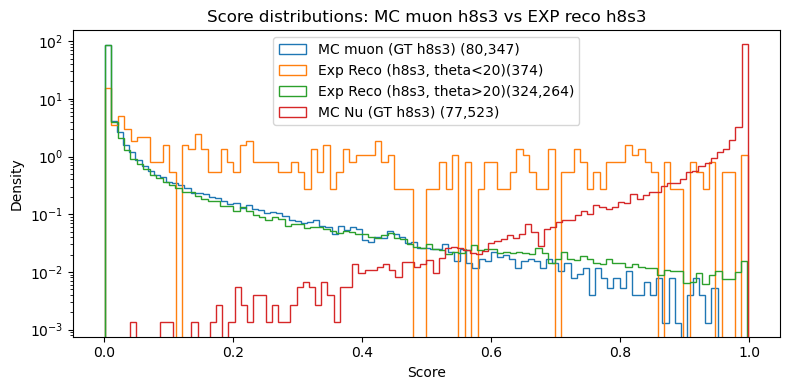

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta30.png


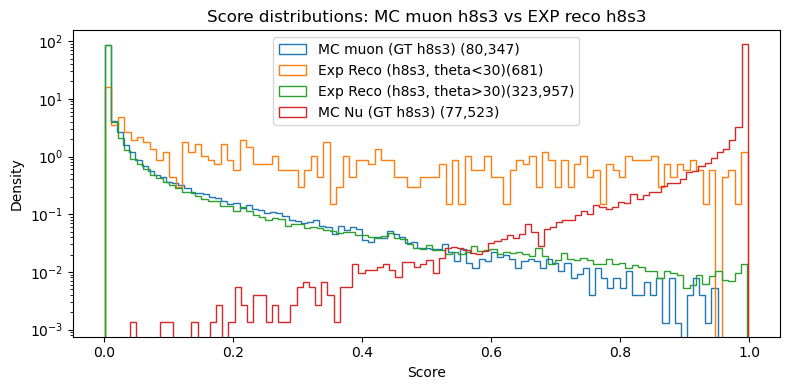

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta40.png


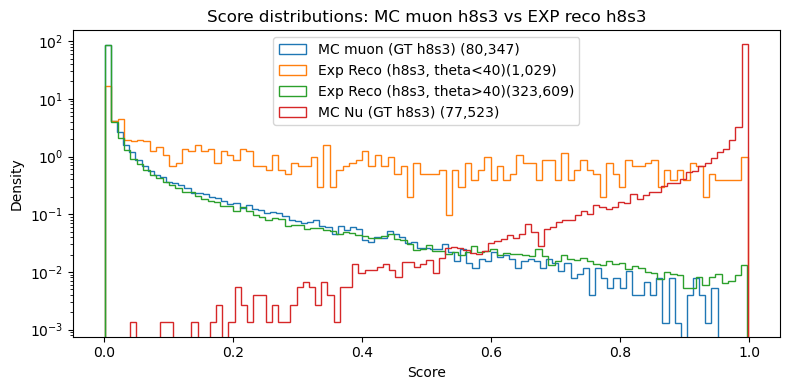

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta60.png


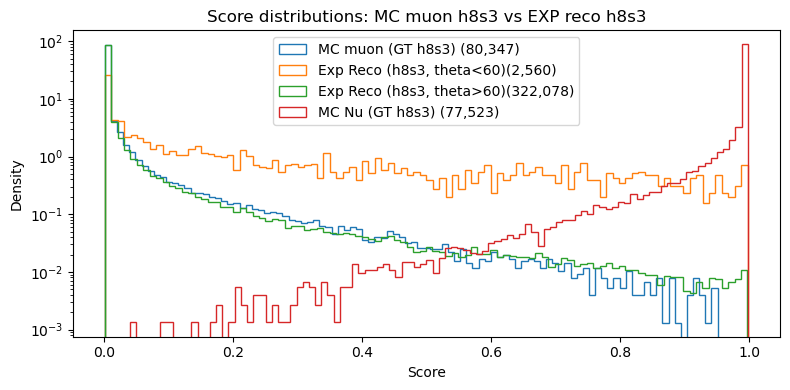

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta80.png


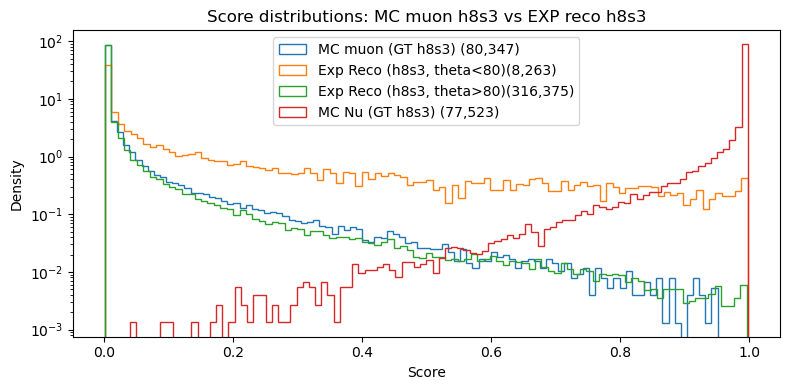

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta90.png


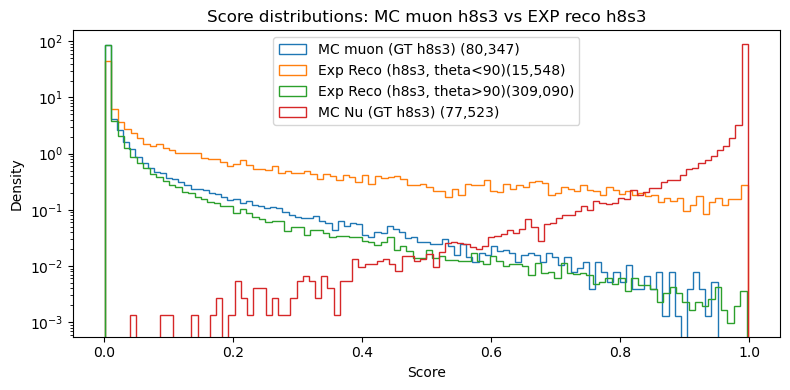

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta120.png


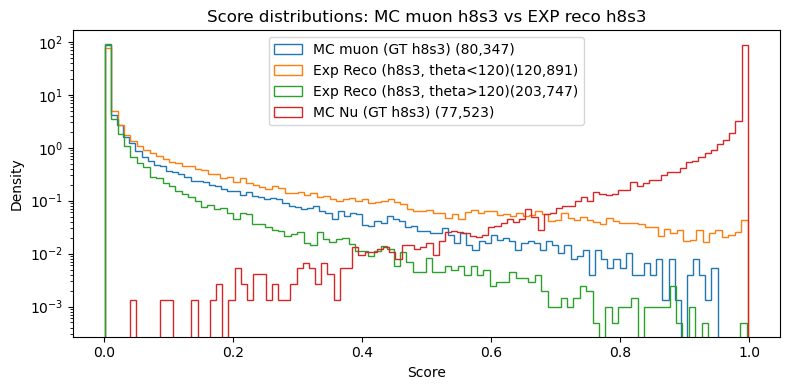

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_mc_vs_exp_reco_theta150.png


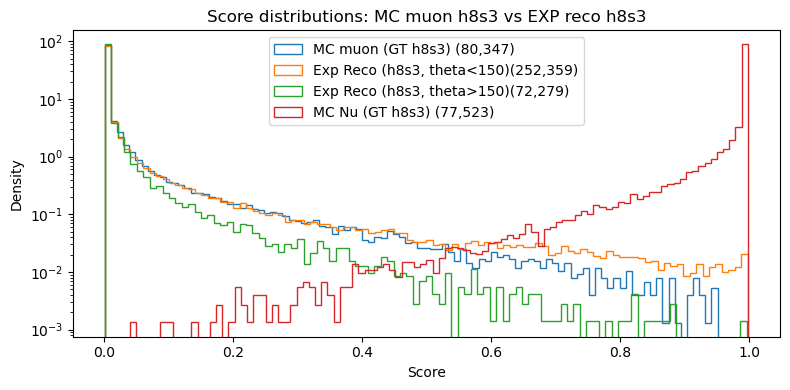

In [14]:
%matplotlib inline
plt.close()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Score distribution per particle type
for ax, ptype in zip(axes, ["muatm", "nue2", "nuatm"]):
    sub = df_mc[df_mc["particle_type"].str.startswith(ptype)]
    ax.hist(sub["score"], bins=100, alpha=0.7, log=True, density=True)
    ax.set_title(f"{ptype} ({len(sub):,} events)")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.set_xlim(0, 1)

plt.tight_layout()
save_figure(fig, "score_dist_per_particle.png", True)
plt.show()

# Score distribution: MC muons vs MC neutrinos vs Exp
fig, ax = plt.subplots(figsize=(8, 4))
mu = df_mc[df_mc["particle_type"].str.startswith("muatm")]["score"]
ax.hist(mu, bins=100, alpha=0.5, log=True, density=True, label=f"MC muon ({len(mu):,})")
#ax.hist(nu, bins=100, alpha=0.5, log=True, density=True, label=f"MC neutrino ({len(nu):,})")
ax.hist(df_exp["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp ({len(df_exp):,})")
#ax.hist(df_exp_reco["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp Reco (h8s3)({len(df_exp):,})")
ax.set_xlabel("Score")
ax.set_ylabel("Density")
ax.legend()
ax.set_title("Score distributions: MC muon vs Exp")
plt.tight_layout()
save_figure(fig, "score_dist_mc_exp.png", True)
plt.show()

# Score distribution: MC muons vs MC neutrinos vs Exp
mu = df_mc[(df_mc["particle_type"].str.startswith("muatm")) & (df_mc["n_signal_hits"]>=8) & (df_mc["n_signal_strings"]>=3)]["score"]
nu = df_mc[(df_mc["particle_type"].str.startswith("nu")) & (df_mc["n_signal_hits"]>=8) & (df_mc["n_signal_strings"]>=3)]["score"]
for theta_cut in [10,20,30,40,60,80,90,120,150]:
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(mu, bins=100, histtype='step', log=True, density=True, label=f"MC muon (GT h8s3) ({len(mu):,})")
    #ax.hist(df_exp["score"], bins=100, alpha=0.5, log=True, density=True, label=f"Exp ({len(df_exp):,})")
    exp_reco_up_score = df_exp_reco["score"][df_exp_reco['thetaRec'] < theta_cut]
    exp_reco_down_score = df_exp_reco["score"][df_exp_reco['thetaRec'] >= theta_cut]
    ax.hist(exp_reco_up_score, bins=100, histtype='step', log=True, density=True, label=f"Exp Reco (h8s3, theta<{theta_cut})({sum(~pd.isna(exp_reco_up_score)):,})")
    ax.hist(exp_reco_down_score, bins=100, histtype='step', log=True, density=True, label=f"Exp Reco (h8s3, theta>{theta_cut})({sum(~pd.isna(exp_reco_down_score)):,})")
    ax.hist(nu, bins=100, histtype='step', log=True, density=True, label=f"MC Nu (GT h8s3) ({len(nu):,})")
    ax.set_xlabel("Score")
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title("Score distributions: MC muon h8s3 vs EXP reco h8s3")
    plt.tight_layout()
    save_figure(fig, f"score_dist_mc_vs_exp_reco_theta{theta_cut}.png", True)
    plt.show()

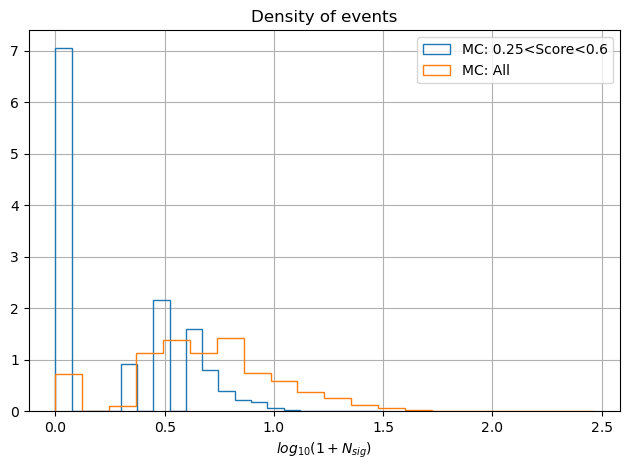

In [15]:
%matplotlib inline
plt.close()
df_mc[(df_mc['score']<0.6) & (df_mc['score']>0.25)]['n_signal_hits'].apply(lambda x: np.log10(x+1)).hist(bins=20, density=True, histtype='step', label='MC: 0.25<Score<0.6')
df_mc['n_signal_hits'].apply(lambda x: np.log10(x+1)).hist(bins=20, density=True, histtype='step', label='MC: All')
plt.xlabel(r"$log_{10}(1+N_{sig})$")
plt.title("Density of events")
plt.legend()
plt.tight_layout()
plt.show()

#### Analyze strange exp_reco events

###### 1. UpGoing events

In [16]:
# %matplotlib inline
# theta_mask = (df_exp_reco['thetaRec'] < 60)
# path_length_mask = (df_exp_reco['pathLength'] > 250)
# func_mask = (df_exp_reco['funcValue'] / (df_exp_reco['nOMs'] - 5) < 30)
# df_upgoing_reco = df_exp_reco[theta_mask & path_length_mask & func_mask]
# df_upgoing_reco = df_exp_reco[df_exp_reco['thetaRec'] > 150]
# df_upgoing_reco['score'].hist(bins=20, log=True)
# plt.title(f"Model WITH DA output distribution\nfor {df_upgoing_reco.shape[0]} upgoing (exp reco) events\nTotal reco events number: {df_exp_reco.shape[0]}.")
# plt.xlabel(r"$P_{\nu}$")
# save_figure(plt.gcf(), "score_dist_upgoing.png")
# plt.show()
# plt.close()

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_upgoing_theta_0_5.png


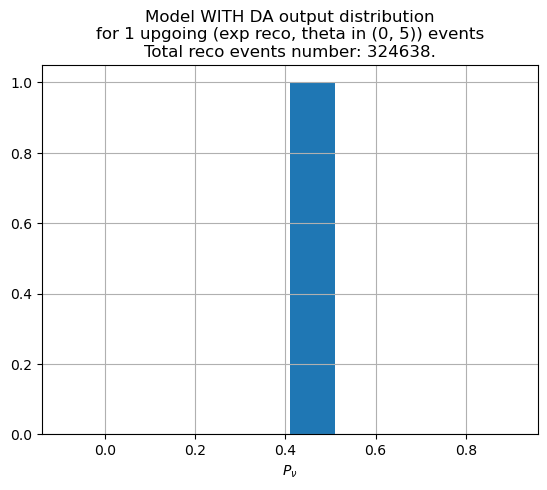

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_upgoing_theta_0_30.png


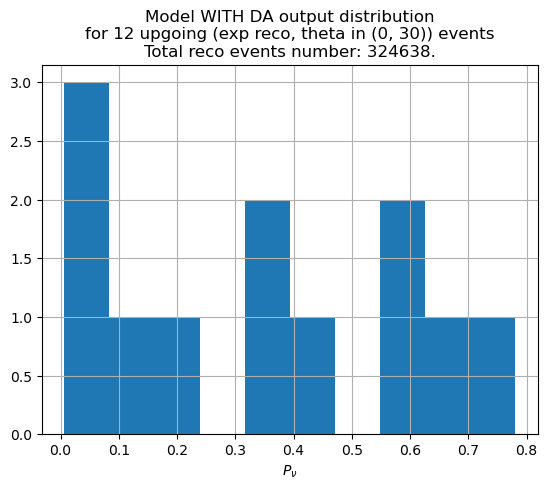

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_upgoing_theta_0_60.png


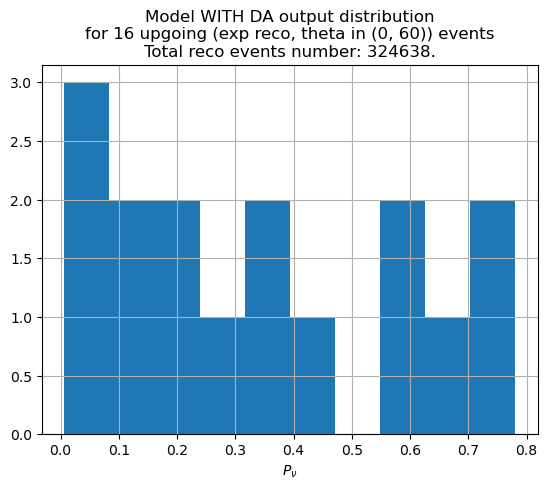

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_dist_upgoing_theta_0_90.png


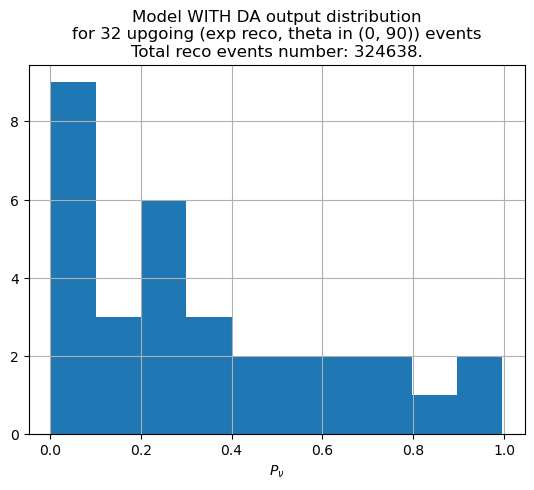

In [17]:
%matplotlib inline
# theta_mask = (df_exp_reco['reco_0']<60)
# path_length_mask = (df_exp_reco['reco_11']>250)
# func_mask = (df_exp_reco['reco_4'] / (df_exp_reco['reco_10']-5) < 30)
# df_upgoing_reco = df_exp_reco[theta_mask & path_length_mask & func_mask]

for theta_cuts in [(0, 5), (0, 30), (0, 60), (0, 90)]:
    df_upgoing_reco = df_exp_reco[get_mask(df_exp_reco, theta_cuts=theta_cuts)]
    df_upgoing_reco['score'].hist(bins=10)
    plt.title(f"Model WITH DA output distribution\nfor {df_upgoing_reco.shape[0]} upgoing (exp reco, theta in {theta_cuts}) events\nTotal reco events number: {df_exp_reco.shape[0]}.")
    plt.xlabel(r"$P_{\nu}$")
    save_figure(plt.gcf(), f"score_dist_upgoing_theta_{theta_cuts[0]}_{theta_cuts[1]}.png")
    plt.show()
    plt.close()

In [18]:
if False:
    %matplotlib ipympl
    plt.close()
    score_mask = (df_upgoing_reco['score']>0.) & (df_upgoing_reco['score']<0.1)
    event_idx = 1
    event = df_upgoing_reco[score_mask].iloc[event_idx]

    theta = event['thetaRec']
    score = event['score']
    feats = event['features']
    signal_mask = event['signal_mask']

    theta_str = r"$\theta$"
    plot_event_3d(feats, signal_mask, f"Reconstructed Event 3D view.\nReco {theta_str} = {theta:.2f} (upgoing if < 90.0)\nMy model score = {score:.3f} (EAS if <<0.5)")
    plt.tight_layout()
    plt.show()

    if False:
        #plt.close()
        #%matplotlib inline
        maxq = df_upgoing_reco['features'][score_mask].apply(lambda x: x[:,0].max())
        df1 = df_upgoing_reco[score_mask].loc[maxq.index]
        df1['MaxQ'] = maxq
        display(df1[['h5_part_str', 'MaxQ']])

###### 1.1 Bad Qmax Found!

In [19]:
if False:
    %matplotlib inline
    plt.close()
    df_mc['features'].apply(lambda x: np.log10(x[:,0].max())).hist()
    plt.show()

    %matplotlib inline
    plt.close()
    df_exp['features'].apply(lambda x: np.log10(x[:,0].max())).hist()
    plt.show()

    %matplotlib inline
    plt.close()
    df_exp_reco['features'].apply(lambda x: np.log10(x[:,0].max())).hist()
    plt.show()

###### 2. Bad T STD Found!

In [20]:
if False:
    df_strange_peak_reco = df_exp_reco[(df_exp_reco['score']>0.35) & (df_exp_reco['score']<0.45)]
    df_strange_nu_reco = df_exp_reco[(df_exp_reco['score']>0.999)]

    display(df_strange_peak_reco['h5_part_str'].value_counts())

    display(df_strange_nu_reco['h5_part_str'].value_counts())

    hist_kwargs = dict(bins=50, histtype='step', density=True)
    muh8s3 = df_mc[(df_mc["particle_type"].str.startswith("muatm")) & (df_mc["n_signal_hits"]>=8) & (df_mc["n_signal_strings"]>=3)]

    # Q
    df_strange_peak_reco['features'].apply(lambda x: np.log10(x[:,0].max())).explode().hist(label='from peak', **hist_kwargs)
    df_strange_nu_reco['features'].apply(lambda x: np.log10(x[:,0].max())).explode().hist(label='from score=1 peak', **hist_kwargs)
    df_exp_reco['features'].apply(lambda x: np.log10(x[:,0].max()))[::10].explode().hist(label='Full exp reco', **hist_kwargs)
    muh8s3['features'].apply(lambda x: np.log10(x[:,0].max())).explode().hist(label='MC muatm h8s3', **hist_kwargs)
    plt.title(f"Max Q hists")
    plt.legend()
    plt.show()

    # Z
    df_strange_peak_reco['features'].apply(lambda x: x[:,4].mean()).explode().hist(label='from peak', **hist_kwargs)
    df_strange_nu_reco['features'].apply(lambda x: x[:,4].mean()).explode().hist(label='from score=1 peak', **hist_kwargs)
    df_exp_reco['features'].apply(lambda x: x[:,4].mean())[::10].explode().hist(label='Full exp reco', **hist_kwargs)
    muh8s3['features'].apply(lambda x: x[:,4].mean()).explode().hist(label='MC muatm h8s3', **hist_kwargs)
    plt.legend()
    plt.title(f"Mean Z coord")
    plt.show()
    print()

    # T
    df_strange_peak_reco['features'].apply(lambda x: x[:,1].std()).explode().hist(label='from peak', **hist_kwargs)
    df_strange_nu_reco['features'].apply(lambda x: x[:,1].std()).explode().hist(label='from score=1 peak', **hist_kwargs)
    df_exp_reco['features'].apply(lambda x: x[:,1].std())[::10].explode().hist(label='Full exp reco', **hist_kwargs)
    muh8s3['features'].apply(lambda x: x[:,1].std()).explode().hist(label='MC muatm h8s3', **hist_kwargs)
    plt.legend()
    plt.title(f"STD T")
    plt.show()
    print()
     
    #Plot STD T by parts (runs)
    print("Std time")
    for cluster in ['c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07']:
        for part in sorted(df_exp_reco['h5_part_str'].unique()):
            if cluster not in part:
                continue
            part_df = df_exp_reco[df_exp_reco['h5_part_str']==part]
            t_std = part_df['features'].apply(lambda x: x[:,1].std())
            t_std.hist(label=part, **hist_kwargs)
        plt.title(f"Cluster {cluster}")
        plt.legend()
        plt.show()

    print("Std time in exp NOT RECO")
    for cluster in ['c01', 'c02', 'c03', 'c04', 'c05', 'c06', 'c07']:
        for part in sorted(df_exp['h5_part_str'].unique()):
            if cluster not in part:
                continue
            part_df = df_exp[df_exp['h5_part_str']==part]
            t_std = part_df['features'].apply(lambda x: x[:,1].std())
            t_std.hist(label=part, **hist_kwargs)
        plt.title(f"Cluster {cluster}")
        plt.legend()
        plt.show()

## 5. Precision-Recall curves (MC)

Binary labels for PR evaluation: **signal** = neutrino events with `n_signal_hits >= h_threshold`, **background** = everything else.

In [21]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_auc_score

# Assign binary labels: neutrino = signal candidate, muon = background
df_mc["is_neutrino"] = df_mc["particle_type"].str.startswith("nu")

# plt.tight_layout()
# plt.show()

Using h_saturate=8 from training config


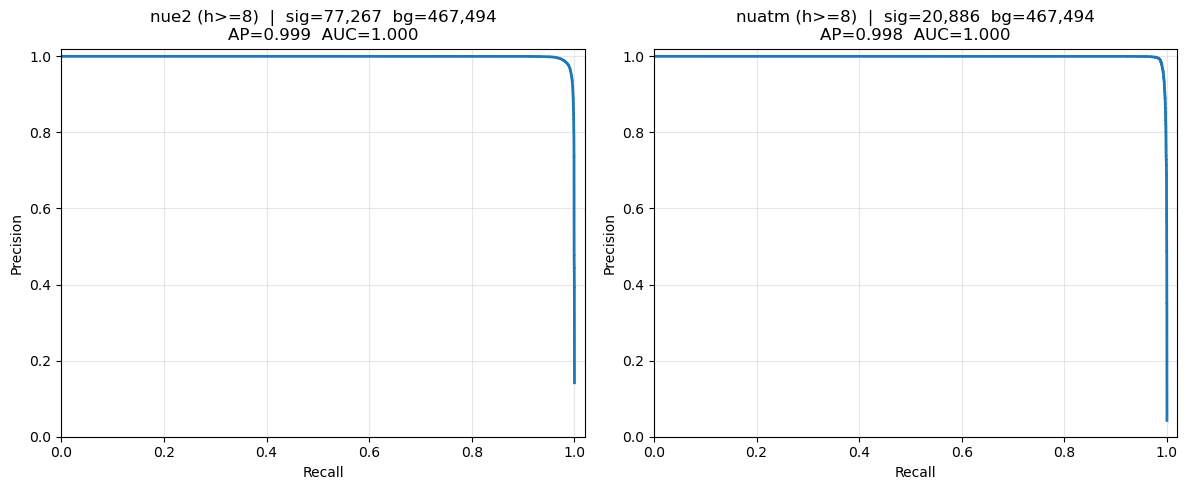

In [22]:
# PR curve split by neutrino type (nue2 vs nuatm) at h_saturate from training
H_SAT = 8 #train_config.get("data", {}).get("source_domain", {}).get("soft_labels", {}).get("h_saturate", 9)
print(f"Using h_saturate={H_SAT} from training config")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, nu_type in zip(axes, ["nue2", "nuatm"]):
    # Signal: this neutrino type with >= H_SAT signal hits
    # Background: muons + low-signal neutrinos of this type
    mask_sig = (df_mc["particle_type"].str.startswith(nu_type)) & (df_mc["n_signal_hits"] >= H_SAT)
    mask_bg = (df_mc["particle_type"].str.startswith('muatm')) | (
        (df_mc["particle_type"] == nu_type) & (df_mc["n_signal_hits"] < H_SAT)
    )
    sub = df_mc[mask_sig | mask_bg]
    binary_label = mask_sig[sub.index].astype(int)
    scores = sub["score"].values

    n_sig = binary_label.sum()
    n_bg = len(binary_label) - n_sig

    precision, recall, _ = precision_recall_curve(binary_label, scores)
    ap = average_precision_score(binary_label, scores)
    auc = roc_auc_score(binary_label, scores)

    ax.plot(recall, precision, lw=2)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title(f"{nu_type} (h>={H_SAT})  |  sig={n_sig:,}  bg={n_bg:,}\nAP={ap:.3f}  AUC={auc:.3f}")
    ax.set_xlim(0, 1.02)
    ax.set_ylim(0, 1.02)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 5c. Signal Efficiency & Background Suppression vs threshold

Twin y-axes: **TPR** (solid, left) and **1/FPR** (dashed, right, log scale) vs classification threshold.

Quality cuts applied symmetrically to both signal and background:
- `No cuts` — all events
- `hits>=8, strings>=2` — `n_signal_hits >= 8` **and** `n_signal_strings >= 2`

Case 1 (both nu types): positives subsampled to match muon count. Dotted vertical line marks **TPR = 99%** for the quality cut, with suppression annotated.

In [23]:
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from sklearn.metrics import roc_curve

# ── Config ──
HIT_CUTS   = [0, 8]
CUT_COLORS = ["grey", None]   # None = default color cycle
CUT_LABELS = ["No cuts", "hits>=8, strings>=3"]
SUPP_CLIP  = 10_000
REF_H      = 8
REF_TPR_TARGET = 0.99

# ── Precompute arrays ──
scores     = df_mc["score"].values
sig_hits   = df_mc["n_signal_hits"].values
sig_strs   = df_mc["n_signal_strings"].values
is_nu      = df_mc["is_neutrino"].values
is_muon    = ~is_nu
ptypes_arr = df_mc["particle_type"].values


def make_quality_mask(h: int) -> np.ndarray:
    """h=0: all events; h>0: signal_hits >= h AND signal_strings >= 2."""
    if h == 0:
        return np.ones(len(df_mc), dtype=bool)
    return (sig_hits >= h) & (sig_strs >= 3)


def balanced_subsample(pos_mask: np.ndarray, seed: int = 42) -> np.ndarray:
    """Subsample positives down to muon count, return mask."""
    n_neg = int(is_muon.sum())
    pos_idx = np.where(pos_mask)[0]
    chosen = np.random.default_rng(seed).choice(pos_idx, size=min(n_neg, len(pos_idx)), replace=False)
    m = np.zeros(len(df_mc), dtype=bool)
    m[chosen] = True
    return m


def get_ref_threshold(pos_mask: np.ndarray, sub_mask: np.ndarray = None):
    """Threshold where TPR ~ REF_TPR_TARGET for REF_H quality cut."""
    base_pos = pos_mask if sub_mask is None else (pos_mask & sub_mask)
    quality = make_quality_mask(REF_H)
    keep = (base_pos & quality) | (is_muon & quality)
    y_true = base_pos[keep].astype(int)
    y_score = scores[keep]
    fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
    # Reverse to ascending threshold order
    thr_arr = thr_arr[1:][::-1]
    tpr_arr = tpr_arr[1:][::-1]
    fpr_arr = fpr_arr[1:][::-1]
    inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
    idx = np.searchsorted(-tpr_arr, -REF_TPR_TARGET)
    idx = min(idx, len(thr_arr) - 1)
    return float(thr_arr[idx]), float(inv_fpr[idx])


def plot_tpr_suppression(ax, pos_mask, title, sub_mask=None):
    """Plot TPR (left y) and 1/FPR (right y, log) vs threshold."""
    ax_supp = ax.twinx()
    ax_supp.set_yscale("log")

    tpr_handles, supp_handles = [], []

    for h, color, lbl in zip(HIT_CUTS, CUT_COLORS, CUT_LABELS):
        base_pos = pos_mask if sub_mask is None else (pos_mask & sub_mask)
        quality = make_quality_mask(h)
        keep = (base_pos & quality) | (is_muon & quality)
        y_true = base_pos[keep].astype(int)
        y_score = scores[keep]
        n_sig, n_bg = y_true.sum(), (~y_true.astype(bool)).sum()
        if n_sig == 0 or n_bg == 0:
            continue

        fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
        thr_arr = thr_arr[1:][::-1]
        tpr_arr = tpr_arr[1:][::-1]
        fpr_arr = fpr_arr[1:][::-1]
        inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
        clip = (thr_arr >= 0) & (thr_arr <= 1)

        ax.plot(thr_arr[clip], tpr_arr[clip], color=color, lw=2, ls="-")
        ax_supp.plot(thr_arr[clip], inv_fpr[clip], color=color, lw=2, ls="--")

        tpr_handles.append(Line2D([0], [0], color=color, lw=2, ls="-",
                                  label=f"{lbl} (#nu={n_sig:,})"))
        supp_handles.append(Line2D([0], [0], color=color, lw=2, ls="--", label=f"{lbl} (#mu={n_bg:,})"))

    # Reference vertical line at TPR=99%
    ref_thr, ref_supp = get_ref_threshold(pos_mask, sub_mask)
    ref_supp_clipped = min(ref_supp, SUPP_CLIP)
    ax.axvline(ref_thr, color="red", lw=1.4, ls=":")
    tpr_handles.append(Line2D([0], [0], color="red", lw=1.4, ls=":",
                               label=f"Saving {int(REF_TPR_TARGET*100)}% nu @ thr={ref_thr:.3f}"))
    ax_supp.annotate(
        f"Supp={ref_supp:.0f}", xy=(ref_thr, ref_supp_clipped),
        xytext=(ref_thr - 0.21, ref_supp_clipped),
        fontsize=11, color="red", fontweight="bold",
        arrowprops=dict(arrowstyle="->", color="red", lw=1.2), va="center",
    )

    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)
    ax_supp.set_ylim(bottom=1)
    ax.set_xlabel("Classification threshold", fontsize=12)
    ax.set_ylabel(r"$\nu$ Efficiency (TPR)", fontsize=11)
    ax_supp.set_ylabel(r"EAS Suppression ($FPR^{-1}$)", fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.xaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.05))
    ax.grid(which="major", alpha=0.3); ax.grid(which="minor", alpha=0.12)

    ax.legend(handles=tpr_handles, fontsize=8.5, loc=(0.01, 0.72),
              framealpha=0.85, title="Efficiency (solid)", title_fontsize=8.5)
    ax_supp.legend(handles=supp_handles, fontsize=8.5, loc=(0.07, 0.1),
                   framealpha=0.85, title="Suppression (dashed)", title_fontsize=8.5)
    return ax_supp

Case 1 balanced: 431,811 positives / 467,494 negatives


/tmp/ipykernel_1866141/3337168037.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1866141/3337168037.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1866141/3337168037.py:51: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
/tmp/ipykernel_1866141/3337168037.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1866141/3337168037.py:78: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), None, SUPP_CLIP)
/tmp/ipykernel_1866141/3337168037.py:51: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/tpr_suppression.png


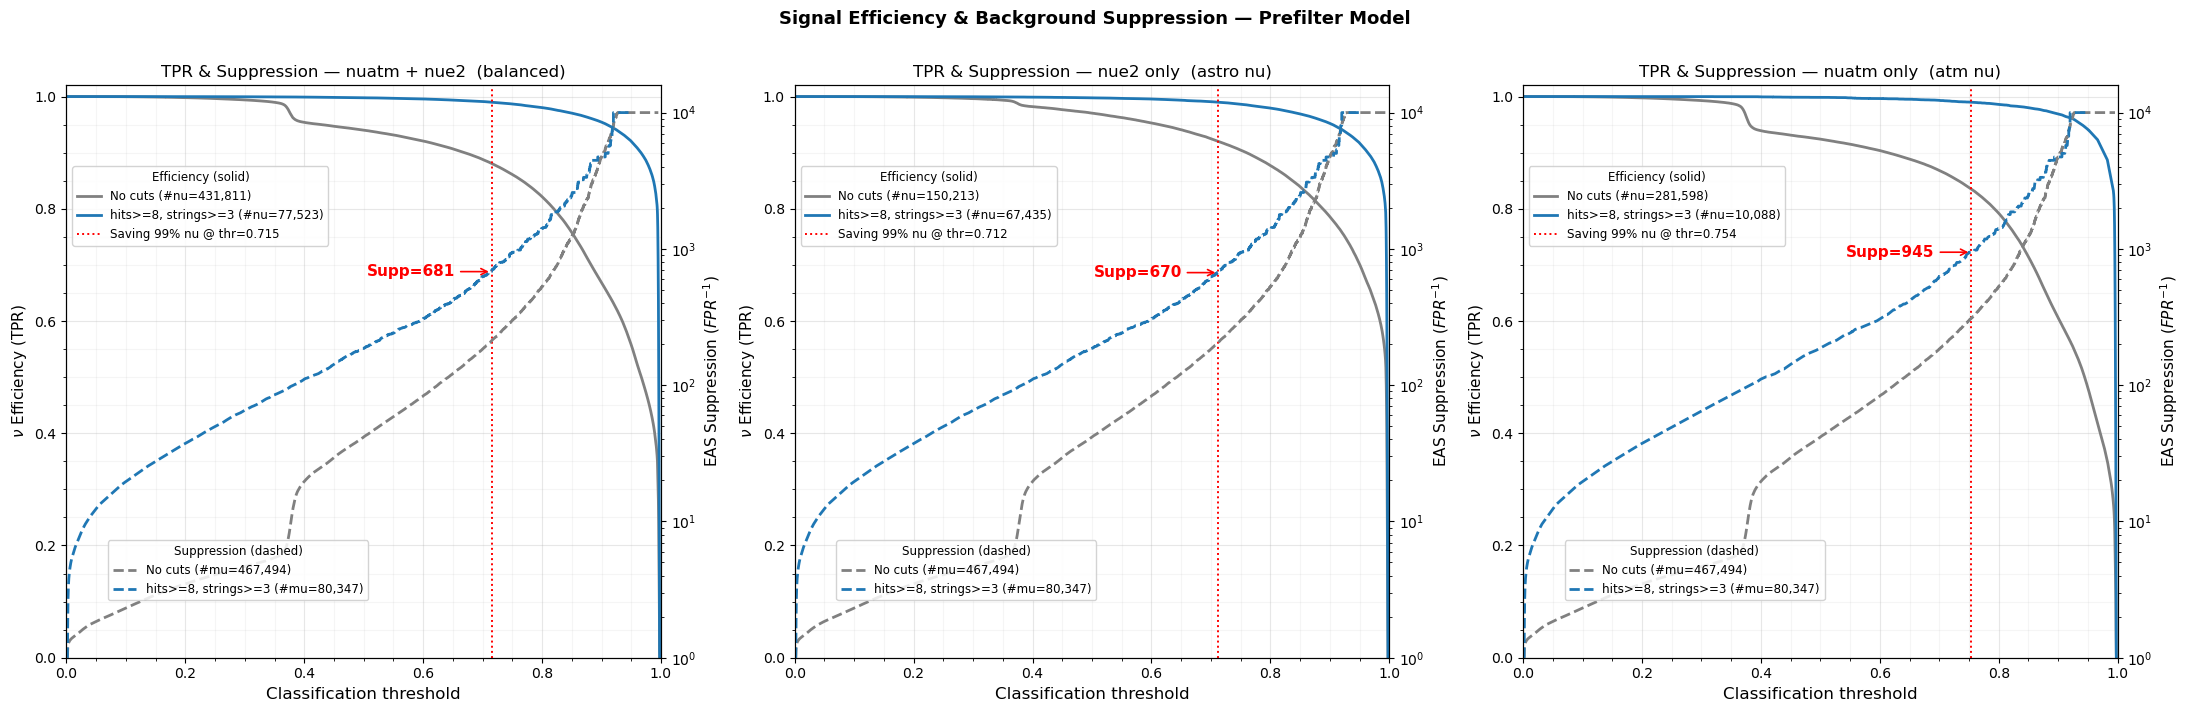

In [24]:
# ── Case 1: Both nuatm + nue2 as signal (balanced) ──
pos_both = is_nu.copy()
sub_both = balanced_subsample(pos_both)
n_pos = (pos_both & sub_both).sum()
n_neg = is_muon.sum()
print(f"Case 1 balanced: {n_pos:,} positives / {n_neg:,} negatives")

# ── Case 2: nue2 only ──
pos_nue2 = (ptypes_arr == "nue2_2020")

# ── Case 3: nuatm only ──
pos_nuatm = (ptypes_arr == "nuatm_2020")

# ── Combined 3x1 figure ──
fig, axes = plt.subplots(1, 3, figsize=(22, 7))

cases = [
    (pos_both,  sub_both, "nuatm + nue2  (balanced)"),
    (pos_nue2,  None,     "nue2 only  (astro nu)"),
    (pos_nuatm, None,     "nuatm only  (atm nu)"),
]

for ax, (pos_mask, sub_mask, label) in zip(axes, cases):
    plot_tpr_suppression(ax, pos_mask, title=f"TPR & Suppression — {label}", sub_mask=sub_mask)

fig.suptitle(
    f"Signal Efficiency & Background Suppression — Prefilter Model",
    fontsize=13, fontweight="bold", y=1.01,
)
fig.tight_layout()
save_figure(fig, "tpr_suppression.png")
plt.show()

## 6. Score vs. Energy & Arrival Angle (MC)

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_vs_energy_theta.png


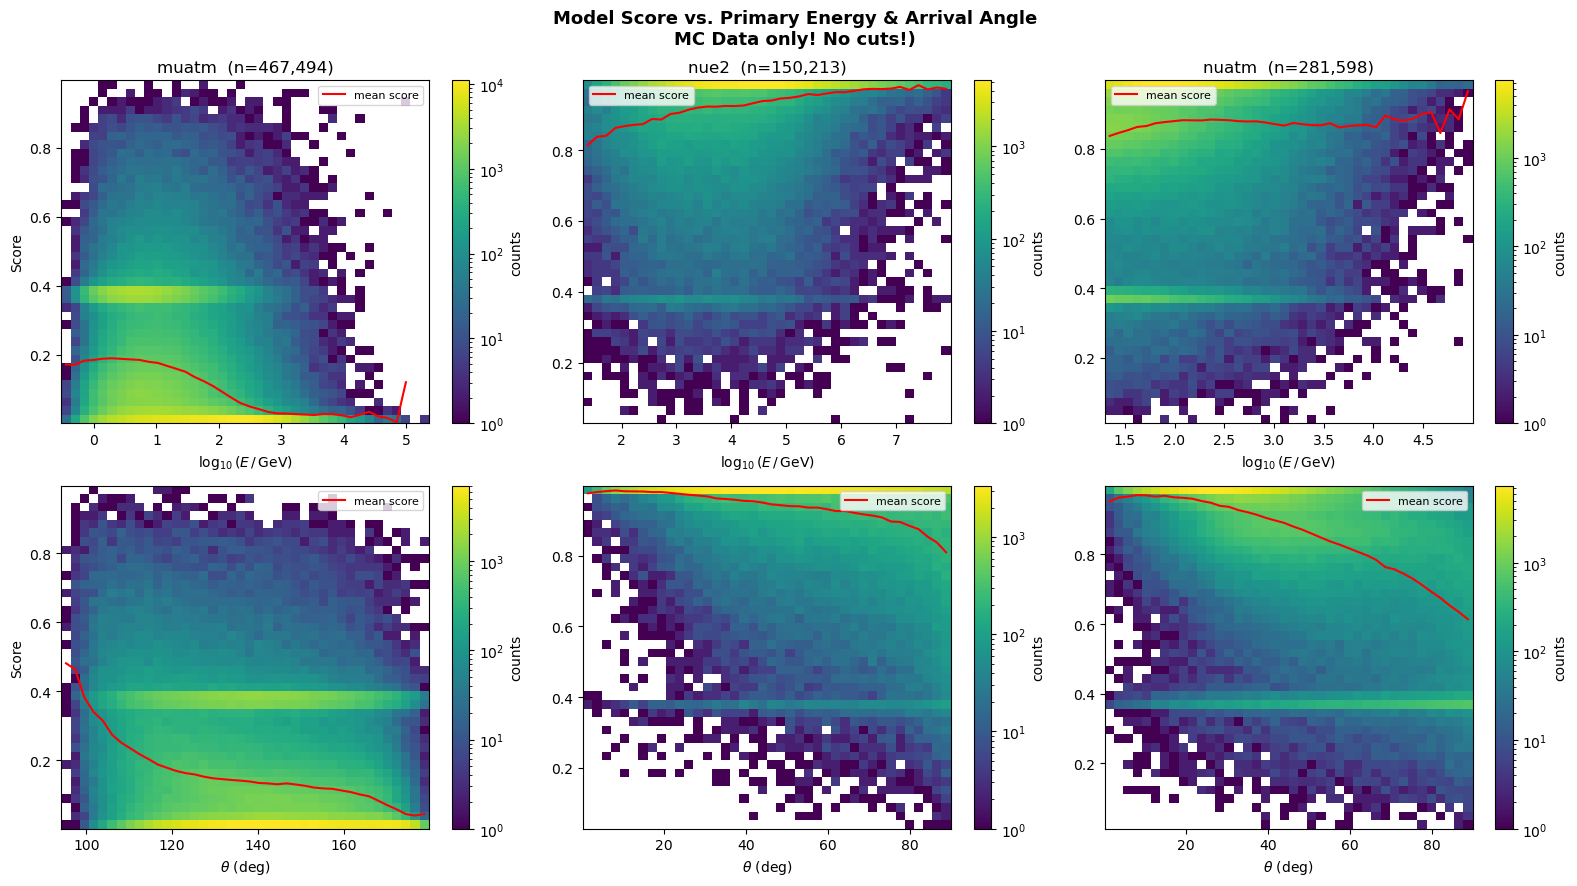

In [25]:
# ── Score vs. Energy & Arrival Angle (MC) ───────────────────────────────────
# Requires energy/theta columns — re-run Section 2 loading cells if missing.
import matplotlib.colors as mcolors

PTYPES = ["muatm_2020", "nue2_2020", "nuatm_2020"]
PTYPE_LABELS = {"muatm_2020": "muatm", "nue2_2020": "nue2", "nuatm_2020": "nuatm"}
N_BINS = 40

if "energy" not in df_mc.columns:
    print("'energy' column not found — re-run the data loading cell (Section 2) with updated utils.py")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    for col_idx, ptype in enumerate(PTYPES):
        sub = df_mc[df_mc["particle_type"] == ptype].dropna(subset=["energy", "theta", "score"])
        if sub.empty:
            axes[0, col_idx].set_visible(False)
            axes[1, col_idx].set_visible(False)
            continue

        log_e = np.log10(sub["energy"].clip(lower=1e-3))
        theta_deg = sub["theta"]
        score = sub["score"]
        label = PTYPE_LABELS[ptype]

        def profile(x, y, bins):
            edges = np.linspace(x.min(), x.max(), bins + 1)
            centers = 0.5 * (edges[:-1] + edges[1:])
            means = [y[(x >= edges[i]) & (x < edges[i+1])].mean() for i in range(bins)]
            return centers, means

        # Row 0: score vs log10(energy)
        ax = axes[0, col_idx]
        h = ax.hist2d(log_e, score, bins=N_BINS, norm=mcolors.LogNorm(), cmap="viridis")
        fig.colorbar(h[3], ax=ax, label="counts")
        cx, cm = profile(log_e, score, N_BINS)
        ax.plot(cx, cm, color="red", lw=1.5, label="mean score")
        ax.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{GeV})$")
        ax.set_ylabel("Score" if col_idx == 0 else "")
        ax.set_title(f"{label}  (n={len(sub):,})")
        ax.legend(fontsize=8)

        # Row 1: score vs theta
        ax = axes[1, col_idx]
        h = ax.hist2d(theta_deg, score, bins=N_BINS, norm=mcolors.LogNorm(), cmap="viridis")
        fig.colorbar(h[3], ax=ax, label="counts")
        cx, cm = profile(theta_deg, score, N_BINS)
        ax.plot(cx, cm, color="red", lw=1.5, label="mean score")
        ax.set_xlabel(r"$\theta$ (deg)")
        ax.set_ylabel("Score" if col_idx == 0 else "")
        ax.legend(fontsize=8)

    fig.suptitle("Model Score vs. Primary Energy & Arrival Angle\nMC Data only! No cuts!)", fontsize=13, fontweight="bold")
    fig.tight_layout()
    save_figure(fig, "score_vs_energy_theta.png")
    plt.show()


Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/score_vs_energy_theta_h8s3.png


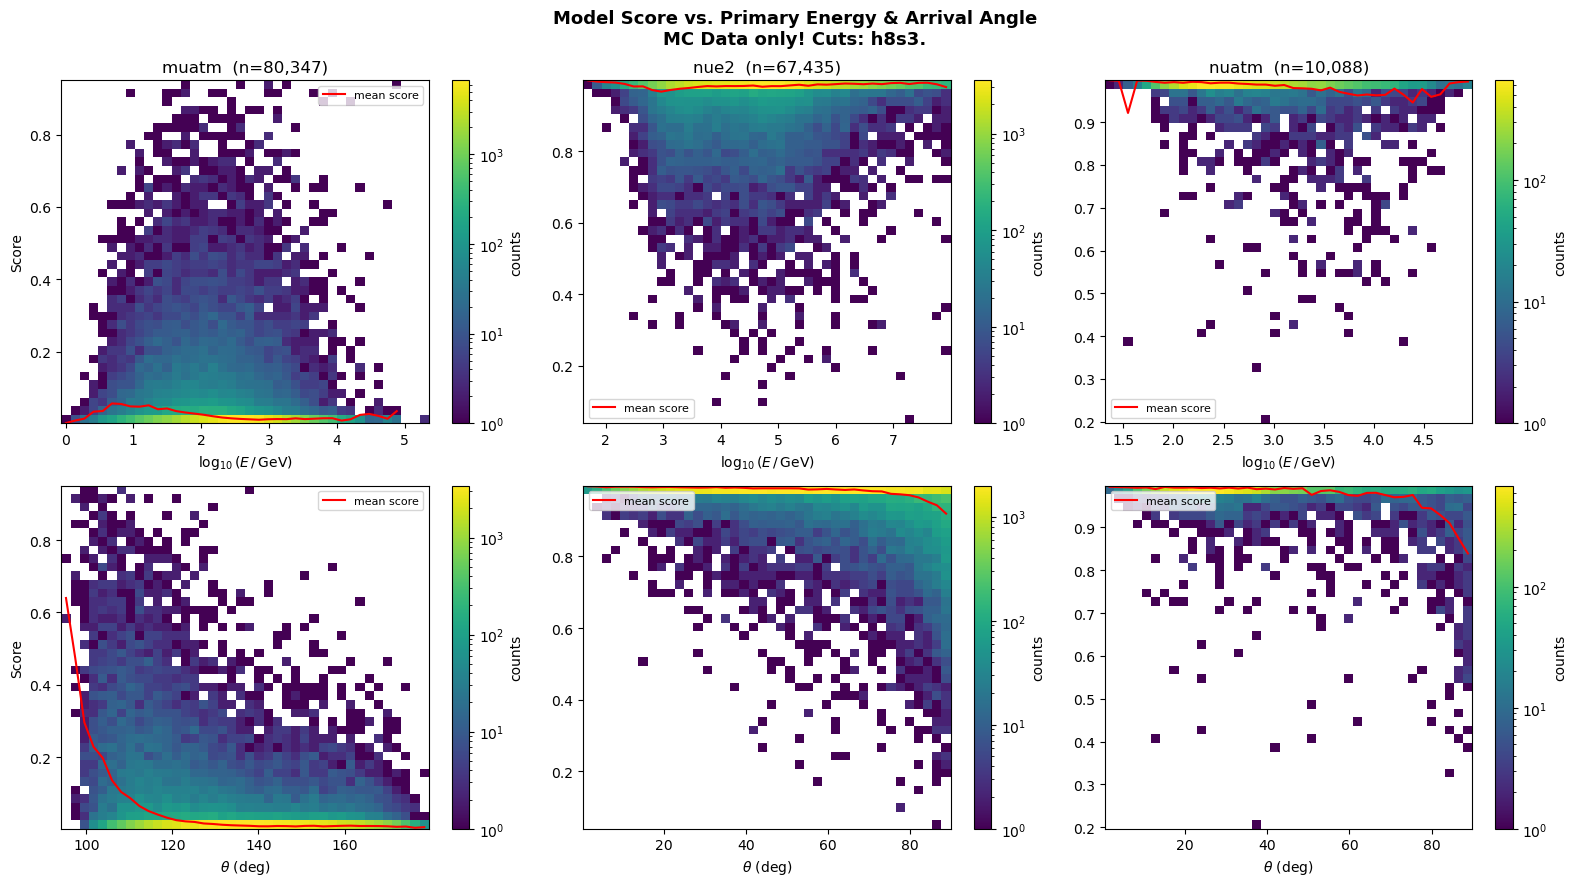

In [26]:
# ── Score vs. Energy & Arrival Angle (MC) ───────────────────────────────────
# Requires energy/theta columns — re-run Section 2 loading cells if missing.
import matplotlib.colors as mcolors

PTYPES = ["muatm_2020", "nue2_2020", "nuatm_2020"]
PTYPE_LABELS = {"muatm_2020": "muatm", "nue2_2020": "nue2", "nuatm_2020": "nuatm"}
N_BINS = 40
HCUT, SCUT = 8, 3

df_mc_cut = df_mc[(df_mc.n_signal_hits>=HCUT) & (df_mc.n_signal_strings>=SCUT)]

if "energy" not in df_mc.columns:
    print("'energy' column not found — re-run the data loading cell (Section 2) with updated utils.py")
else:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))

    for col_idx, ptype in enumerate(PTYPES):
        sub = df_mc_cut[df_mc_cut["particle_type"] == ptype].dropna(subset=["energy", "theta", "score"])
        if sub.empty:
            axes[0, col_idx].set_visible(False)
            axes[1, col_idx].set_visible(False)
            continue

        log_e = np.log10(sub["energy"].clip(lower=1e-3))
        theta_deg = sub["theta"]
        score = sub["score"]
        label = PTYPE_LABELS[ptype]

        def profile(x, y, bins):
            edges = np.linspace(x.min(), x.max(), bins + 1)
            centers = 0.5 * (edges[:-1] + edges[1:])
            means = [y[(x >= edges[i]) & (x < edges[i+1])].mean() for i in range(bins)]
            return centers, means

        # Row 0: score vs log10(energy)
        ax = axes[0, col_idx]
        h = ax.hist2d(log_e, score, bins=N_BINS, norm=mcolors.LogNorm(), cmap="viridis")
        fig.colorbar(h[3], ax=ax, label="counts")
        cx, cm = profile(log_e, score, N_BINS)
        ax.plot(cx, cm, color="red", lw=1.5, label="mean score")
        ax.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{GeV})$")
        ax.set_ylabel("Score" if col_idx == 0 else "")
        ax.set_title(f"{label}  (n={len(sub):,})")
        ax.legend(fontsize=8)

        # Row 1: score vs theta
        ax = axes[1, col_idx]
        h = ax.hist2d(theta_deg, score, bins=N_BINS, norm=mcolors.LogNorm(), cmap="viridis")
        fig.colorbar(h[3], ax=ax, label="counts")
        cx, cm = profile(theta_deg, score, N_BINS)
        ax.plot(cx, cm, color="red", lw=1.5, label="mean score")
        ax.set_xlabel(r"$\theta$ (deg)")
        ax.set_ylabel("Score" if col_idx == 0 else "")
        ax.legend(fontsize=8)

    fig.suptitle(f"Model Score vs. Primary Energy & Arrival Angle\nMC Data only! Cuts: h{HCUT}s{SCUT}.", fontsize=13, fontweight="bold")
    fig.tight_layout()
    save_figure(fig, f"score_vs_energy_theta_h{HCUT}s{SCUT}.png")
    plt.show()


## 7. Model Stability Under Augmentation

Check how much the model score changes when the same event is repeatedly augmented (rotation + Gaussian noise), sweeping the noise scale factor from 0× to 4× the training level.

- **Violin plot** — score distribution across augmentations at training-level noise (scale=1.0)
- **Std vs noise scale** — mean ± std of score std across events, per class

In [27]:
# ── Augmentation helpers ──────────────────────────────────────────────────────

def augment_event(
    features: np.ndarray,
    noise_std: list,
    rotation: bool,
    rng: np.random.RandomState,
) -> np.ndarray:
    """Apply random rotation + Gaussian noise + time re-sort to one event.

    Args:
        features: (n_hits, 5) array [amp, time, x, y, z].
        noise_std: Per-feature noise standard deviations (len 5).
        rotation: Whether to apply random azimuthal rotation.
        rng: RandomState for reproducibility.

    Returns:
        Augmented (n_hits, 5) array, sorted by time.
    """
    feat = features.copy().astype(np.float32)

    if rotation:
        angle = rng.uniform(0.0, 2.0 * np.pi)
        cos_a, sin_a = np.cos(angle), np.sin(angle)
        x, y = feat[:, 2].copy(), feat[:, 3].copy()
        feat[:, 2] = cos_a * x - sin_a * y
        feat[:, 3] = sin_a * x + cos_a * y

    if noise_std is not None:
        noise = rng.randn(*feat.shape).astype(np.float32) * np.array(noise_std, dtype=np.float32)
        feat = feat + noise

    # Re-sort by time (keep ordering stable after noise)
    feat = feat[np.argsort(feat[:, 1])]
    return feat


def collect_augmented_scores(
    features_list: list,
    noise_std_base: list,
    noise_scales: list,
    n_aug: int,
    model,
    norm_config: dict,
    device: str = "cpu",
    seed: int = 0,
) -> np.ndarray:
    """Score each event under multiple augmentations and noise strengths.

    Returns:
        scores: float32 array of shape (n_events, n_scales, n_aug).
    """
    rng = np.random.RandomState(seed)
    n_events = len(features_list)
    n_scales = len(noise_scales)
    scores = np.zeros((n_events, n_scales, n_aug), dtype=np.float32)

    for si, scale in enumerate(noise_scales):
        scaled_noise = [s * scale for s in noise_std_base] if scale > 0 else None
        aug_feats = [
            augment_event(feat, scaled_noise, rotation=True, rng=rng)
            for feat in features_list
            for _ in range(n_aug)
        ]
        batch_scores = predict_scores(
            model, aug_feats, norm_config, batch_size=512, max_hits=MAX_HITS, device=DEVICE
        )
        scores[:, si, :] = batch_scores.reshape(n_events, n_aug)

    return scores

In [28]:
# ── Stability sweep configuration ────────────────────────────────────────────

N_AUG       = 100     # augmentations per event per noise scale
N_PER_CLASS = 10      # MC events sampled per particle type
NOISE_SCALES = [0.0, 0.25, 0.5, 1.0, 2.0, 4.0]  # × training noise_std
NOISE_STD_BASE = train_config["dataloader"]["augmentation"]["noise_std"]  # from checkpoint

rng_sel = np.random.RandomState(SEED)

# Sample events: high-signal mu, nue2, nuatm + exp
stability_events = []
stability_labels = []  # class name per event

for ptype in ["muatm", "nue2", "nuatm"]:
    pool = df_mc[df_mc["particle_type"].str.startswith(ptype)]
    pool = pool[pool["n_hits"] >= 20]
    sel = pool.sample(n=min(N_PER_CLASS, len(pool)), random_state=rng_sel)
    stability_events.extend(sel["features"].tolist())
    stability_labels.extend([ptype] * len(sel))

# Optional: a few exp events
exp_sel = df_exp.sample(n=min(N_PER_CLASS, len(df_exp)), random_state=rng_sel)
stability_events.extend(exp_sel["features"].tolist())
stability_labels.extend(["exp"] * len(exp_sel))

stability_labels = np.array(stability_labels)
print(f"Stability test: {len(stability_events)} events × {N_AUG} augmentations × {len(NOISE_SCALES)} scales")

stab_scores = collect_augmented_scores(
    stability_events, NOISE_STD_BASE, NOISE_SCALES,
    n_aug=N_AUG, model=model, norm_config=norm_config,
    device=DEVICE, seed=SEED,
)
print(f"Scores array shape: {stab_scores.shape}  (events × scales × augmentations)")

Stability test: 40 events × 100 augmentations × 6 scales


Predicting:   0%|          | 0/8 [00:00<?, ?batch/s]

Predicting:   0%|          | 0/8 [00:00<?, ?batch/s]

Predicting:   0%|          | 0/8 [00:00<?, ?batch/s]

Predicting:   0%|          | 0/8 [00:00<?, ?batch/s]

Predicting:   0%|          | 0/8 [00:00<?, ?batch/s]

Predicting:   0%|          | 0/8 [00:00<?, ?batch/s]

Scores array shape: (40, 6, 100)  (events × scales × augmentations)


Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/stability_violin.png


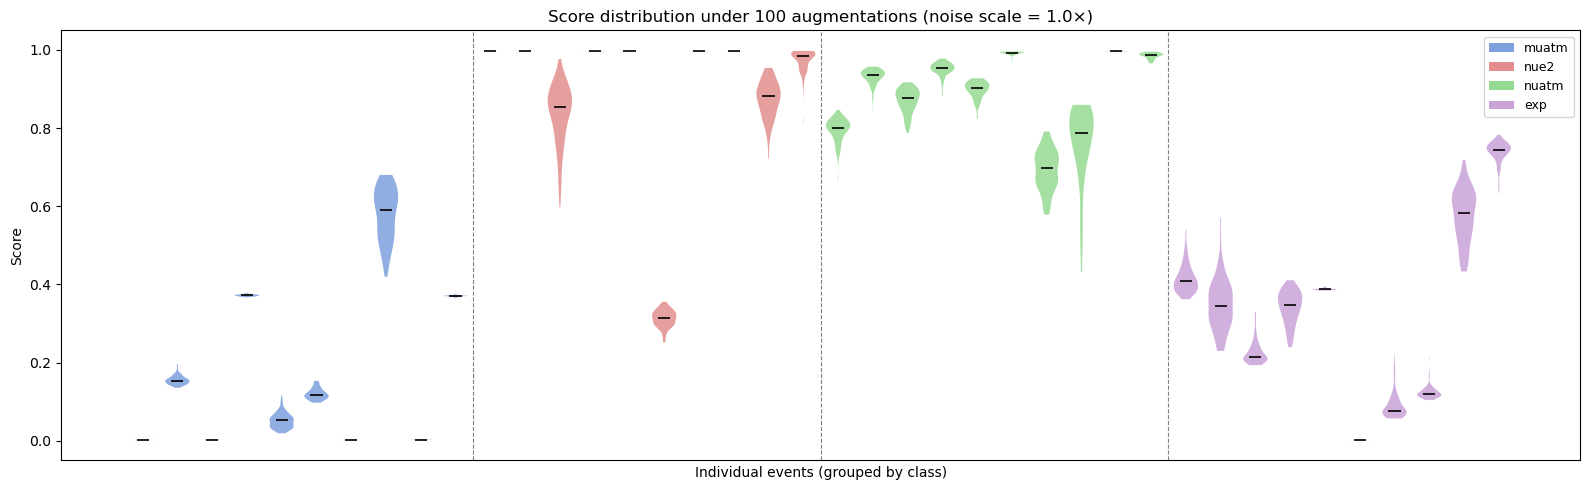

In [29]:
# ── Plot 1: score distributions at training noise level (scale = 1.0) ────────

train_scale_idx = NOISE_SCALES.index(1.0)
scores_at_1x = stab_scores[:, train_scale_idx, :]  # (n_events, n_aug)

CLASS_COLORS = {"muatm": "#4878CF", "nue2": "#D65F5F", "nuatm": "#6ACC65", "exp": "#B47CC7"}
classes_ordered = ["muatm", "nue2", "nuatm", "exp"]

fig, ax = plt.subplots(figsize=(max(12, len(stability_events) * 0.4), 5))

positions = np.arange(len(stability_events))
for i, (feat_scores, label) in enumerate(zip(scores_at_1x, stability_labels)):
    color = CLASS_COLORS.get(label, "grey")
    vp = ax.violinplot(feat_scores, positions=[i], widths=0.7, showmedians=True, showextrema=False)
    for part in vp["bodies"]:
        part.set_facecolor(color)
        part.set_alpha(0.6)
    vp["cmedians"].set_color("black")
    vp["cmedians"].set_linewidth(1.2)

# Legend
from matplotlib.patches import Patch
handles = [Patch(facecolor=CLASS_COLORS[c], alpha=0.7, label=c) for c in classes_ordered]
ax.legend(handles=handles, loc="upper right", fontsize=9)

# Class separator lines
boundaries = []
prev = stability_labels[0]
for i, lbl in enumerate(stability_labels):
    if lbl != prev:
        boundaries.append(i - 0.5)
        prev = lbl
for b in boundaries:
    ax.axvline(b, color="grey", lw=0.8, linestyle="--")

ax.set_xticks([])
ax.set_xlabel("Individual events (grouped by class)")
ax.set_ylabel("Score")
ax.set_ylim(-0.05, 1.05)
ax.set_title(f"Score distribution under {N_AUG} augmentations (noise scale = 1.0×)")
fig.tight_layout()
save_figure(fig, "stability_violin.png")
plt.show()

Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260430_0846_Qclip_hardlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_FocalLoss/figures_260501_193056/stability_std_vs_noise_scale.png


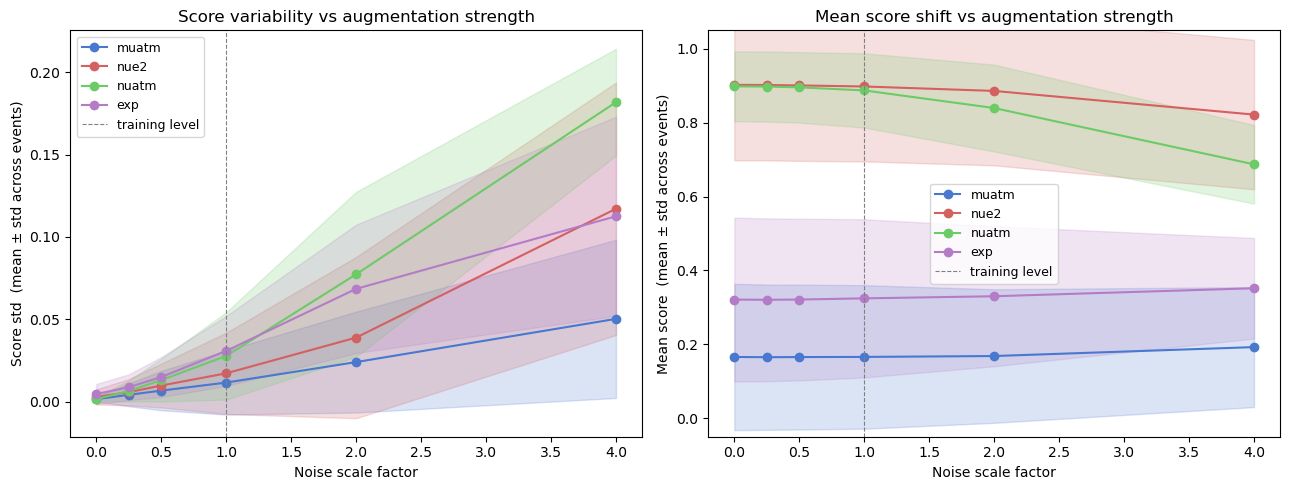

: 

In [ ]:
# ── Plot 2: score std vs noise scale ─────────────────────────────────────────

# stab_scores: (n_events, n_scales, n_aug)
score_std = stab_scores.std(axis=2)   # (n_events, n_scales)
score_mean = stab_scores.mean(axis=2) # (n_events, n_scales)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for class_name in classes_ordered:
    mask = stability_labels == class_name
    if not mask.any():
        continue
    color = CLASS_COLORS[class_name]
    class_std = score_std[mask]   # (n_class_events, n_scales)
    class_mean = score_mean[mask]

    mean_std = class_std.mean(axis=0)
    se_std   = class_std.std(axis=0)

    axes[0].plot(NOISE_SCALES, mean_std, marker="o", color=color, label=class_name)
    axes[0].fill_between(NOISE_SCALES, mean_std - se_std, mean_std + se_std, alpha=0.2, color=color)

    mean_score = class_mean.mean(axis=0)
    se_score   = class_mean.std(axis=0)
    axes[1].plot(NOISE_SCALES, mean_score, marker="o", color=color, label=class_name)
    axes[1].fill_between(NOISE_SCALES, mean_score - se_score, mean_score + se_score, alpha=0.2, color=color)

axes[0].axvline(1.0, color="grey", lw=0.8, linestyle="--", label="training level")
axes[0].set_xlabel("Noise scale factor")
axes[0].set_ylabel("Score std  (mean ± std across events)")
axes[0].set_title("Score variability vs augmentation strength")
axes[0].legend(fontsize=9)

axes[1].axvline(1.0, color="grey", lw=0.8, linestyle="--", label="training level")
axes[1].set_xlabel("Noise scale factor")
axes[1].set_ylabel("Mean score  (mean ± std across events)")
axes[1].set_title("Mean score shift vs augmentation strength")
axes[1].legend(fontsize=9)
axes[1].set_ylim(-0.05, 1.05)

fig.tight_layout()
save_figure(fig, "stability_std_vs_noise_scale.png")
plt.show()